In [19]:
from vectorbtpro import *
import os
import sys

from zoneinfo import ZoneInfo
from datetime import datetime
from dateutil.relativedelta import relativedelta

import seaborn as sns
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from tqdm import tqdm
import requests

In [2]:
# retrieve API keys from environment
api_keys = dict()
with open(".env") as f:
    for line in f.readlines():
        elems = line.split("=")
        api_keys[elems[0].strip()] = elems[1].strip()

In [3]:
vbt.PolygonData.set_custom_settings(
    client_config=dict(
        api_key=api_keys['POLYGON_API_KEY']
    )
)

In [29]:
local_tz = datetime.now().astimezone().tzinfo
t0 = (datetime.now(local_tz) - relativedelta(years=4))
t1 = datetime.now(local_tz)
print(f"[{t0.strftime("%Y-%m-%d")}, {t1.strftime("%Y-%m-%d")}]")

[2022-06-19, 2026-06-19]


In [144]:
data = vbt.PolygonData.pull(
    ["X:BTCUSD","X:ETHUSD"],
    start=t0.strftime("%Y-%m-%d"),
    end=t1.strftime("%Y-%m-%d"),
    timeframe="4 hours",
    tz=str(local_tz)
)

  0%|          | 0/2 [00:02<?, ?it/s, symbol=X:BTCUSD]

3it [00:02,  1.43it/s, 2022-06-18 13:00 → 2022-09-30 01:00]

In [145]:
data.features

['Open', 'High', 'Low', 'Close', 'Volume', 'Trade count', 'VWAP']

In [15]:
df_bgeo = pd.DataFrame()
for feature in ['mvrv-zscore', 'sopr', 'nupl']:
    resp = requests.get(f"https://api.bgeometrics.com/v1/{feature}?token={api_keys['BGEOMETRICS_API_KEY']}")
    if(resp.status_code == 200):
        metric = pd.DataFrame(resp.json())
        metric['unixTs']=pd.to_datetime(metric['unixTs'], unit='s')
        metric.set_index('unixTs', inplace=True)
        metric.index = metric.index.tz_localize(local_tz)
        metric.drop(columns=['d'], inplace=True)
        df_bgeo = pd.concat((df_bgeo, metric), axis=1)
    else:
        resp_data = resp.json()
        print(f"ERROR {resp.status_code} ({resp_data['error']['code']}): {resp_data['error']['message']}")
        break;

                          mvrvZscore
unixTs                              
2022-06-19 00:00:00+01:00    -0.1488
2022-06-20 00:00:00+01:00     -0.142
2022-06-21 00:00:00+01:00    -0.1311
2022-06-22 00:00:00+01:00    -0.1755
2022-06-23 00:00:00+01:00    -0.0993
                             sopr
unixTs                           
2022-06-19 00:00:00+01:00  0.9983
2022-06-20 00:00:00+01:00  0.9955
2022-06-21 00:00:00+01:00  0.9927
2022-06-22 00:00:00+01:00  0.9858
2022-06-23 00:00:00+01:00  0.9961
                             nupl
unixTs                           
2022-06-19 00:00:00+01:00 -0.1007
2022-06-20 00:00:00+01:00 -0.0993
2022-06-21 00:00:00+01:00 -0.0897
2022-06-22 00:00:00+01:00 -0.1274
2022-06-23 00:00:00+01:00 -0.0664


In [34]:
df_bgeo.set_index(data.index, inplace=True)

In [138]:
df = pd.concat((
    data.vwap.rename(columns={'X:BTCUSD':'BTCUSD_VWAP', 'X:ETHUSD':'ETHUSD_VWAP'}),
    data.close.rename(columns={'X:BTCUSD':'BTCUSD', 'X:ETHUSD':'ETHUSD'}),
    df_bgeo),
    axis=1
)

In [139]:
ret = df['BTCUSD'].pct_change()
df['vol5']  = ret.rolling(5).std().shift(-5)
df['vol28'] = ret.rolling(28).std().shift(-28)
df['vol90'] = ret.rolling(90).std().shift(-90)

In [140]:
df.dropna(inplace=True)
df_corr = df.corr().loc[['vol5','vol28','vol90']].drop(columns=['vol5','vol28','vol90'])
df_corr

,BTCUSD_VWAP,ETHUSD_VWAP,BTCUSD,ETHUSD,mvrvZscore,sopr,nupl
vol5,-0.059869,-0.029857,-0.060167,-0.032522,-0.013555,-0.051974,-0.020600
vol28,-0.147604,-0.055066,-0.147641,-0.055735,-0.079190,-0.042359,-0.085075
vol90,-0.237782,-0.001588,-0.238277,-0.002715,-0.147069,-0.078048,-0.179368


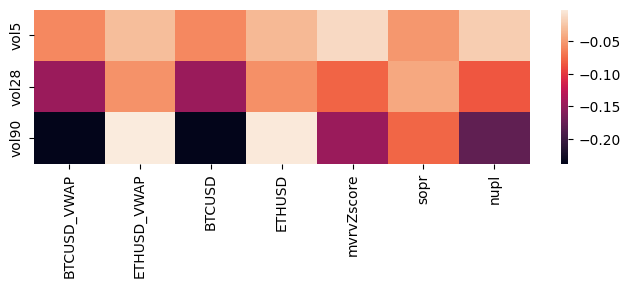

In [141]:
fig, ax = plt.subplots(1,1,figsize=(8,2))
sns.heatmap(df_corr, ax=ax)
plt.show()

In [152]:
log_rets = np.log(data.close).diff() # 4h log returns: equivalent to log(P_t / P_{t-1})
# Daily realized variance = sum of squared intraday log returns per day
rv = (log_rets ** 2).resample('1D').sum(min_count=1) 
# resample('1D') respects the +11:00 timezone when grouping by calendar day, so day boundaries are correct for your local tz
rv.columns = ['RV_BTCUSD', 'RV_ETHUSD']

In [157]:
df_bgeo.set_index(rv.index, inplace=True)

In [159]:
df1 = pd.concat((rv, df_bgeo), axis=1)

In [161]:
df1.corr()

,RV_BTCUSD,RV_ETHUSD,mvrvZscore,sopr,nupl
RV_BTCUSD,1.000000,0.771989,-0.039480,-0.002552,-0.075490
RV_ETHUSD,0.771989,1.000000,0.007378,-0.015582,-0.059920
mvrvZscore,-0.039480,0.007378,1.000000,0.538164,0.926692
sopr,-0.002552,-0.015582,0.538164,1.000000,0.517795
nupl,-0.075490,-0.059920,0.926692,0.517795,1.000000


In [189]:
raw_rebal_dates = pd.date_range(t0,t1, freq='5d', tz=local_tz)
raw_rebal_indices = df1.index.searchsorted(raw_rebal_dates, side='left').clip(0,df1.shape[0]-1)
adj_rebal_dates = df1.index[raw_rebal_indices]

In [195]:
df1.index

DatetimeIndex(['2022-06-19 00:00:00+11:00', '2022-06-20 00:00:00+11:00',
               '2022-06-21 00:00:00+11:00', '2022-06-22 00:00:00+11:00',
               '2022-06-23 00:00:00+11:00', '2022-06-24 00:00:00+11:00',
               '2022-06-25 00:00:00+11:00', '2022-06-26 00:00:00+11:00',
               '2022-06-27 00:00:00+11:00', '2022-06-28 00:00:00+11:00',
               ...
               '2026-06-09 00:00:00+11:00', '2026-06-10 00:00:00+11:00',
               '2026-06-11 00:00:00+11:00', '2026-06-12 00:00:00+11:00',
               '2026-06-13 00:00:00+11:00', '2026-06-14 00:00:00+11:00',
               '2026-06-15 00:00:00+11:00', '2026-06-16 00:00:00+11:00',
               '2026-06-17 00:00:00+11:00', '2026-06-18 00:00:00+11:00'],
              dtype='datetime64[ns, UTC+11:00]', name='Open time', length=1461, freq='D')

In [200]:
saved_model = 
for i in pd.date_range(df1.index[365],df1.index[-1], freq='5d'):


1
6
11
16
21
26
31
36
41
46
51
56
61
66
71
76
81
86
91
96
101
106
111
116
121
126
131
136
141
146
151
156
161
166
171
176
181
186
191
196
201
206
211
216
221
226
231
236
241
246
251
256
261
266
271
276
281
286
291
296
301
306
311
316
321
326
331
336
341
346
351
356
361
366
371
376
381
386
391
396
401
406
411
416
421
426
431
436
441
446
451
456
461
466
471
476
481
486
491
496
501
506
511
516
521
526
531
536
541
546
551
556
561
566
571
576
581
586
591
596
601
606
611
616
621
626
631
636
641
646
651
656
661
666
671
676
681
686
691
696
701
706
711
716
721
726
731
736
741
746
751
756
761
766
771
776
781
786
791
796
801
806
811
816
821
826
831
836
841
846
851
856
861
866
871
876
881
886
891
896
901
906
911
916
921
926
931
936
941
946
951
956
961
966
971
976
981
986
991
996
1001
1006
1011
1016
1021
1026
1031
1036
1041
1046
1051
1056
1061
1066
1071
1076
1081
1086
1091
1096
1101
1106
1111
1116
1121
1126
1131
1136
1141
1146
1151
1156
1161
1166
1171
1176
1181
1186
1191
1196
1201
1206
1211
1216
12

In [197]:
import requests

resp = requests.get(
  "https://www.deribit.com/api/v2/public/get_volatility_index_data",
  params={
      "currency": "BTC",
      "start_timestamp": int(t0.timestamp() * 1000),  # milliseconds
      "end_timestamp":   int(t1.timestamp() * 1000),
      "resolution": "1D"   # "60", "3600", "1D"
  }
)
dvol = pd.DataFrame(
  resp.json()["result"]["data"],
  columns=["timestamp", "open", "high", "low", "close"]
)
dvol["timestamp"] = pd.to_datetime(dvol["timestamp"], unit="ms", utc=True).dt.tz_convert(local_tz)
dvol.set_index("timestamp", inplace=True)

In [198]:
dvol

,open,high,low,close
timestamp,,,,
2023-09-24 01:00:00+01:00,37.64,39.92,36.61,38.60
2023-09-25 01:00:00+01:00,38.60,40.34,38.00,39.25
2023-09-26 01:00:00+01:00,39.25,40.45,38.51,38.67
2023-09-27 01:00:00+01:00,38.67,39.64,35.54,36.06
2023-09-28 01:00:00+01:00,36.06,40.38,35.39,38.63
...,...,...,...,...
2026-06-15 01:00:00+01:00,40.33,40.33,38.25,38.72
2026-06-16 01:00:00+01:00,38.72,39.14,36.70,37.67
2026-06-17 01:00:00+01:00,37.67,40.46,36.71,39.54
